# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Face Mask Detection using Convolutional Neural Networks

## Learning Objectives

At the end of the miniproject, you will be able to :

* load and extract features of images using ImageDataGenerator

* build the convolutional neural networks

* use the pre-trained models using keras applications

## Introduction

This project uses a Deep Neural Network, more specifically a Convolutional Neural Network, to differentiate between images of people, with masks, without masks and incorrectly placed masks. Manually built and pretrained networks will be used to perform this classification task.

**Face-Mask-Detection-Using-CNN**

* Outbreak of the Coronavirus pandemic has created various changes in the lifestyle of everyone around the world.
* Among these changes, wearing a mask has been very vital to every individual.
* Detection of people who are not wearing masks is a challenge due to the large populations.
* This face mask detection project can be used in schools, hospitals, banks, airports etc as a digitalized scanning tool. 
  - The technique of detecting people’s faces and segregating them into three classes namely the people with masks and people without masks and partial masks is done with the help of image processing and deep learning.
* With the help of this project, a person who is monitoring the face mask status for a particular firm can be seated in a remote area and still monitor efficiently and give instructions accordingly.

![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/dataset-images-with-mask.jpg)

## Dataset

The data for this mini-project is collected from various sources including the masked images from internet and general frontal face images considered as without mask. This dataset consists of 5029 train images and 1059 test images with 3 classes `with_mask`, `without_mask` and `partial_mask`

Many people are not correctly wearing their masks due to bad practices, bad behaviors or vulnerability of individuals (e.g., children, old people). For these reasons, several mask wearing campaigns intend to sensitize people about this problem and good practices. In this sense, this work proposes three types of masked face detection dataset; namely, the Correctly Masked Face, the Incorrectly Masked Face and their combination for the global masked face detection. This dataset serves the objective of classifying faces that are: 
  
- Without Mask/ With Mask/ Partial Mask
  
Note that this dataset contains some annotated (artificially generated) masks to augment the 'masked' data category.

## Problem Statement

To build and implement a Convolutional Neural Network model to classify between masked/unmasked/partially masked faces.

## Grading = 10 Points

In [1]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/MP2_FaceMask_Dataset.zip
!unzip -qq MP2_FaceMask_Dataset.zip
print("Data Downloaded Successfuly!!")

replace MP2_FaceMask_Dataset/train/with_mask/-110603108-gettyimages-533567012.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Data Downloaded Successfuly!!


### Import Required packages

In [2]:
import numpy as np
import PIL
from matplotlib import pyplot as plt
import glob, os
import tensorflow as tf
from tensorflow import keras
from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense,Dropout
from keras.models import Model, load_model
from keras.callbacks import TensorBoard, ModelCheckpoint
from PIL import Image
import os.path

## Data Loading and preprocessing (2 points)

### Analyze the shape of images and distribution of classes

In [3]:
!ls  /content/MP2_FaceMask_Dataset/test/partial_mask | wc -l #323
!ls  /content/MP2_FaceMask_Dataset/test/with_mask | wc -l #406
!ls  /content/MP2_FaceMask_Dataset/test/without_mask | wc -l #534
!ls  /content/MP2_FaceMask_Dataset/train/partial_mask | wc -l #1294
!ls  /content/MP2_FaceMask_Dataset/train/with_mask | wc -l #1624
!ls  /content/MP2_FaceMask_Dataset/train/without_mask | wc -l #2138

# Later in the MiniProject, it says to 
# Convert the image to numpy array and resize to the shape which model accept.
# Extend the dimension (to 4-D shape) of an image, as the model is trained on a batch of inputs.

323
406
534
1294
1624
2138


In [4]:
# Images which are of odd dimensions: dict_error_pic_size = {}
# Images which are of non jpeg format : dict_non_jpeg_pic = {}
# Number of images which are not 1024X1024 =  4702
# Number of images which are not supported format =  28


test_pm = "/content/MP2_FaceMask_Dataset/test/partial_mask"
test_wm = "/content/MP2_FaceMask_Dataset/test/with_mask"
test_wom = "/content/MP2_FaceMask_Dataset/test/without_mask"
train_pm = "/content/MP2_FaceMask_Dataset/train/partial_mask"
train_wm = "/content/MP2_FaceMask_Dataset/train/with_mask"
train_wom = "/content/MP2_FaceMask_Dataset/train/without_mask"

dict_error_pic_size = {}
dict_unsupported_format_pic = {}
dict_supported_format_pic = {}

supported1 = ["JPEG","jpeg"]
supported2 = ["jpg","JPG"]

def check_images(check_dir):
  for pic in os.listdir(check_dir):
      filename = os.path.join(check_dir, pic)
      # Retaining jpg, JPG, jpeg, JPEG, png, PNG, gif, GIF
      if((filename[-3:] not in supported2) & (filename[-4:] not in supported1)):
      #if ((filename[-3:] != "jpg") & (filename[-4:] != "jpeg") & (filename[-4:] != "JPEG") & (filename[-3:] != "JPG") & (filename[-3:] != "PNG") & (filename[-3:] != "png") & (filename[-3:] != "GIF") & (filename[-3:] != "gif")):
        print("Error: unsupported file format", filename)
        dict_unsupported_format_pic[filename] = filename[-4:]

      img = Image.open(filename)
      img_shape = img.size
      height = img.size[0]
      width = img.size[1]
      #print(pic, img_shape,height,width)
      if((height != 1024) | (width != 1024)):
        dict_error_pic_size[filename] = img.size
        #print("Found error size")

check_images(test_pm)
check_images(test_wm)
check_images(test_wom)
check_images(train_pm)
check_images(train_wm)
check_images(train_wom)

dict_error_pic_size
#dict_unsupported_format_pic
print("Number of images which are not 1024X1024 = ", len(dict_error_pic_size.keys()))
# Number of images which are not 1024X1024 =  4702

print("Number of images which are not supported format = ", len(dict_unsupported_format_pic.keys()))
# Number of images which are not supported format =  28
#dict_error_pic_size
len(dict_supported_format_pic.keys())

Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/novas (11).png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on290.png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on299.png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on310.png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on318.png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/novas (1).jfif
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on309.png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/novas (3).png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on295.png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/with_mask/novas (8).png
Error: unsupported file format /content/MP2_FaceMask_Dataset/test/wi

0

In [5]:
# Method 1
# Handle the non 1024X1024 files ----> this is Method 1 only. In Method 2, we resize the image to 150X150 ---> 4702 files
import os
def handle_non_compliant_size_images():
  for pic in dict_error_pic_size.keys():
    if os.path.exists(pic):
      print("Removing file: ",pic)
      os.remove(pic)
    else:
      print("The file does not exist: ", pic)

# Handle the non jpeg/png files by deleting them ---> 28 files
def handle_non_compliant_format_images():
  for pic in dict_unsupported_format_pic.keys():
    if os.path.exists(pic):
      print("Removing file: ",pic)
      os.remove(pic)
    else:
      print("The file does not exist: ", pic)

In [6]:
# Not invoking for now. Will convert to 160X160 from various image sizes using the tf.keras.preprocessing.image_dataset_from_directory command
# Below function can drop all images which are no 1024X1024, meaning 4702 images (entire test/train set for with and without mask data)

# handle_non_compliant_size_images() #4674 files which are not 1024X1024 only

In [7]:
# Handle the unsupported image formats, delete 28 files
handle_non_compliant_format_images()

Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/novas (11).png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on290.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on299.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on310.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on318.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/novas (1).jfif
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on309.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/novas (3).png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on295.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/novas (8).png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/novas (1).webp
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/imagen_m_on316.png
Removing file:  /content/MP2_FaceMask_Dataset/test/with_mask/n

### Load the images using ImageDataGenerator

There are two main steps involved in creating the generator.
1. Instantiate ImageDataGenerator with required arguments to create an object
2. Use the `flow_from_directory` command depending on how your data is stored on disk. This is the command that will allow you to generate and get access to batches of data on the fly.

Hint: [link](https://keras.io/api/preprocessing/image/)

In [8]:
# Documentation from given Keras link: "Supported image formats: jpeg, png, bmp, gif. Animated gifs are truncated to the first frame."
# In given dataset, we have files in following formats: jpeg, png, webp, gif, jfif
# There are 28 such files - looks like webp, jfif should be either converted to supported format or dropped

In [9]:
TRAINING_DIR = "/content/MP2_FaceMask_Dataset/train/"
VALIDATION_DIR = "/content/MP2_FaceMask_Dataset/test/"

In [10]:
# Method 2
# For convenience, set up variables to use while pre-processing the dataset and training the network.
batch_size = 128
epochs = 40 # 5029/128 ~ 40
IMG_HEIGHT = 224
IMG_WIDTH = 224

In [11]:
# Method 2
import tensorflow as tf

# Instantiate ImageDataGenerator
train_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our training data
validation_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our validation data

In [12]:
# Method 2 # Found 5029 images belonging to 3 classes.

train_data_gen = train_image_generator.flow_from_directory(directory=TRAINING_DIR,
                                                           shuffle=False,
                                                           target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                           seed=123)
                                                           #class_mode='binary') # There are 3 classes

Found 4978 images belonging to 3 classes.


In [13]:
# Method 2 # Found 1259 images belonging to 3 classes.

val_data_gen = validation_image_generator.flow_from_directory(directory=VALIDATION_DIR,
                                                              shuffle=False,
                                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              seed=123)
                                                              #class_mode='binary') # There are 3 classes

Found 1247 images belonging to 3 classes.


### Visualize the sample images of each class using data generator

Hint: plt.subplot

In [14]:
# The next function returns a batch from the dataset. 
# The return value of next function is in form of (x_train, y_train) 
# where x_train is training features and y_train is its labels

sample_training_images, sample_training_labels = next(train_data_gen)
sample_test_images, sample_test_labels = next(val_data_gen)

In [15]:
# This function will plot images in the form of a grid with 1 row and 5 columns where images are placed in each column.
def plotImages(images_arr, labels_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img, label, ax in zip( images_arr, labels_arr, axes):
        ax.imshow(img)
        ax.set_title(label, fontstyle='italic')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.7/dist-packages/matplotlib/text.py:1165: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


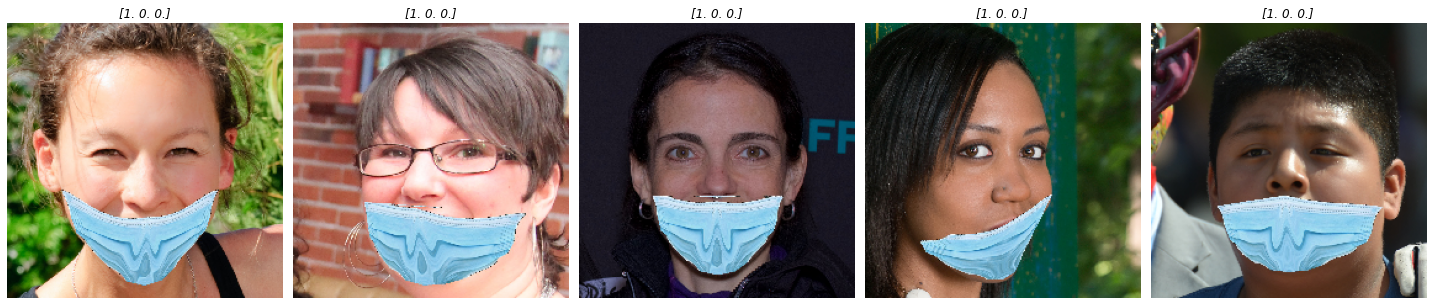

In [16]:
plotImages(sample_training_images[:5], sample_training_labels[:5])

## Build the CNN model using Keras (4 points)



**Convolutional Neural Network:** A neural network in which at least one layer is a convolutional layer. A typical convolutional neural network consists of some combination of the following layers:

* convolutional layers
* pooling layers
* dense layers


**Conv2D**  

Passing an image with input shape of 3-D and to calculate the output: 

 $O = \frac{n - f + 2p}{s} + 1$

**MaxPool** 

The resulting output, when using the "valid" padding option, has a spatial shape (number of rows or columns) of: 

O = `math.floor`$(\frac{input shape - pool size)}{ strides}) + 1$ (when input shape >= pool size)

The resulting output shape when using the "same" padding option is: 

O = `math.floor`$(\frac{input shape - 1}{strides}) + 1$

by default, stride = None, so stride is same as pool size

Task-flow
* Initialize the network of convolution, maxpooling and dense layers
* Define the optimizer and loss functions
* Fit the model and evaluate the model

In [17]:
# Create model
model = Sequential([
                    Conv2D(64, 7, activation="relu", strides=1, padding="same", input_shape=[224, 224, 3]),
                    MaxPooling2D(2),
                    Conv2D(128, 3, activation="relu", strides=1, padding="same"),
                    Conv2D(128, 3, activation="relu", strides=1, padding="same"),
                    MaxPooling2D(2),
                    Conv2D(256, 3, activation="relu", strides=1, padding="same"),
                    Conv2D(256, 3, activation="relu", strides=1, padding="same"),
                    MaxPooling2D(2),
                    Flatten(),
                    Dense(128, activation="relu"),
                    Dropout(0.5),
                    Dense(64, activation="relu"),
                    Dropout(0.5),
                    Dense(3, activation="softmax")
                    ])

In [18]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer="nadam", metrics=["accuracy"])

In [19]:
#history = model.fit_generator(
#            train_data_gen
#            )

In [20]:
x_train = tf.keras.preprocessing.image_dataset_from_directory(
    TRAINING_DIR,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=123,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=True
)

Found 4978 files belonging to 3 classes.


In [21]:
x_test = tf.keras.utils.image_dataset_from_directory(
  VALIDATION_DIR,
  #validation_split=0.2,
  #subset="validation",
  seed=123,
  image_size=(224, 224),
  batch_size=32)

Found 1247 files belonging to 3 classes.


In [22]:
AUTOTUNE = tf.data.AUTOTUNE

x_train = x_train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
x_test = x_test.cache().prefetch(buffer_size=AUTOTUNE)

In [23]:
#history = model.fit(datagen.flow(sample_training_images, sample_training_labels, batch_size=32),
#                     steps_per_epoch=len(x_train) // 32, epochs=epochs)

In [24]:
# Train the model
#history = model.fit(train_batches,
#                    steps_per_epoch = X_train.shape[0]//batch_size,
#                    epochs = 1,
#                    validation_data = val_batches,
#                    validation_steps = X_val.shape[0]//batch_size)

In [25]:
# Load the TensorBoard notebook extension
#%load_ext tensorboard
#import tensorflow as tf
#import datetime
# Clear any logs from previous runs
#rm -rf ./logs/

In [26]:
#log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [27]:
#%tensorboard --logdir logs/fit

In [29]:
#history = model.fit(x=x_train, epochs=1,callbacks=[tensorboard_callback])
history = model.fit(x=x_train, epochs=1)

156/156 [==============================] - 49s 229ms/step - loss: 3.8611 - accuracy: 0.4190


In [30]:
model.save('mp2_cnn.h5')

In [31]:
y_pred = model.predict(x_test)
y_pred[:5]

array([[0.2935786 , 0.32089704, 0.3855244 ],
       [0.29212207, 0.3197405 , 0.38813743],
       [0.29089513, 0.32278186, 0.38632298],
       [0.29337302, 0.31886005, 0.3877669 ],
       [0.29379517, 0.32022968, 0.38597515]], dtype=float32)

In [ ]:
def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(3))
  plt.yticks([])
  thisplot = plt.bar(range(3), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

In [ ]:
sample_test_labels[:5]

In [ ]:

plot_value_array(1, y_pred[0],sample_test_labels[0])
plt.xticks(range(3), class_names, rotation=45)
plt.show()

In [ ]:
plotImages(sample_training_images[:5], sample_training_labels[:5])

## Transfer learning (4 points)

Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.

A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task.

The intuition behind transfer learning for image classification is that if a model is trained on a large and general enough dataset, this model will effectively serve as a generic model of the visual world. You can then take advantage of these learned feature maps without having to start from scratch by training a large model on a large dataset.

For eg. Using VGG16, we remove the last layer which takes a probability for each of the 1000 classes in the ImageNet and replaces it with a layer that takes 3 probabilities in our case.

### Use the pre-trained models ([VGG16](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16) or [ResNet50](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50))

* Load the pre-trained model
* Fit and evaluate the data

Hint: [How to use pre-trained model](https://towardsdatascience.com/step-by-step-guide-to-using-pretrained-models-in-keras-c9097b647b29)

#### Expected accuracy: More than 90%

Task-flow
* Initialize the network with the weights of Imagenet
* Fine tune the network by modifying fully connected layers.
* Re-train the model with our problem data

In [32]:
# Load pretrained ResNet50 model
restnet = ResNet50(include_top=False, weights='imagenet', input_shape=([224, 224, 3]))
op = restnet.layers[-1].output
op = keras.layers.Flatten()(op)
restnet = Model(restnet.input, op)
for layer in restnet.layers:
    layer.trainable = False
restnet.summary()



94781440/94765736 [==============================] - 2s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                             

In [33]:
# https://towardsdatascience.com/deep-learning-using-transfer-learning-python-code-for-resnet50-8acdfb3a2d38
from keras import optimizers

restnetmodel = Sequential()
restnetmodel.add(restnet)
restnetmodel.add(Dense(512, activation='relu', input_dim=[224, 224, 3]))
restnetmodel.add(Dropout(0.3))
restnetmodel.add(Dense(512, activation='relu'))
restnetmodel.add(Dropout(0.3))
restnetmodel.add(Dense(3, activation='sigmoid'))
restnetmodel.compile(loss='categorical_crossentropy', metrics=['accuracy'])
restnetmodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model (Functional)          (None, 100352)            23587712  
                                                                 
 dense_3 (Dense)             (None, 512)               51380736  
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_4 (Dense)             (None, 512)               262656    
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_5 (Dense)             (None, 3)                 1539      
                                                                 
Total params: 75,232,643
Trainable params: 51,644,931


In [51]:
history = restnetmodel.fit(x=x_train, epochs=10)

Epoch 1/10
156/156 [==============================] - 17s 108ms/step - loss: 0.4326 - accuracy: 0.9887
Epoch 2/10
156/156 [==============================] - 17s 108ms/step - loss: 0.1877 - accuracy: 0.9934
Epoch 3/10
156/156 [==============================] - 17s 109ms/step - loss: 0.2991 - accuracy: 0.9930
Epoch 4/10
156/156 [==============================] - 17s 109ms/step - loss: 0.1347 - accuracy: 0.9962
Epoch 5/10
156/156 [==============================] - 17s 110ms/step - loss: 0.1304 - accuracy: 0.9972
Epoch 6/10
156/156 [==============================] - 17s 110ms/step - loss: 0.1109 - accuracy: 0.9972
Epoch 7/10
156/156 [==============================] - 17s 110ms/step - loss: 0.0516 - accuracy: 0.9988
Epoch 8/10
156/156 [==============================] - 17s 111ms/step - loss: 0.1567 - accuracy: 0.9980
Epoch 9/10
156/156 [==============================] - 17s 111ms/step - loss: 0.0259 - accuracy: 0.9992
Epoch 10/10
156/156 [==============================] - 17s 111ms/step - l

In [ ]:
restnetmodel.save('mp2_cnn_restnet50.h5')

### Capture the live image using the below code cell and predict

In [ ]:
#@title Capture the photo
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))
  display(Image(filename))
except Exception as err:
  print(str(err))

After executing above cell and capturing the photo, load the captured photo and predict with model.

**Note:** 
* Convert the image to numpy array and resize to the shape which model accept. 
* Extend the dimension (to 4-D shape) of an image, as the model is trained on a batch of inputs.

In [69]:
y_pred_restnet = restnetmodel.predict(x_test)
y_pred_restnet[:5]

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 4.7377524e-34, 1.0000000e+00],
       [0.0000000e+00, 1.0000000e+00, 3.5847423e-32],
       [0.0000000e+00, 4.5932488e-34, 1.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [38]:
kaggle_pred_path = "/content/FaceMask_Kaggle_test"
check_images(kaggle_pred_path)
#handle_non_compliant_format_images()
#sort_files_by_name()

In [41]:
# https://github.com/keras-team/keras/issues/3946
!mv /content/FaceMask_Kaggle_test/* /content/FaceMask_Kaggle_test/images/
!ls /content/FaceMask_Kaggle_test/images


mv: cannot move '/content/FaceMask_Kaggle_test/images' to a subdirectory of itself, '/content/FaceMask_Kaggle_test/images/images'
100.jpg  168.jpg  234.jpg  300.jpg  368.jpg  434.jpg  500.jpg  568.jpg	634.jpg
101.jpg  169.jpg  235.jpg  301.jpg  369.jpg  435.jpg  501.jpg  569.jpg	635.jpg
102.jpg  16.jpg   236.jpg  302.jpg  36.jpg   436.jpg  502.jpg  56.jpg	636.jpg
103.jpg  170.jpg  237.jpg  303.jpg  370.jpg  437.jpg  503.jpg  570.jpg	637.jpg
104.jpg  171.jpg  238.jpg  304.jpg  371.jpg  438.jpg  504.jpg  571.jpg	638.jpg
105.jpg  172.jpg  239.jpg  305.jpg  372.jpg  439.jpg  505.jpg  572.jpg	639.jpg
106.jpg  173.jpg  23.jpg   306.jpg  373.jpg  43.jpg   506.jpg  573.jpg	63.jpg
107.jpg  174.jpg  240.jpg  307.jpg  374.jpg  440.jpg  507.jpg  574.jpg	640.jpg
108.jpg  175.jpg  241.jpg  308.jpg  375.jpg  441.jpg  508.jpg  575.jpg	641.jpg
109.jpg  176.jpg  242.jpg  309.jpg  376.jpg  442.jpg  509.jpg  576.jpg	642.jpg
10.jpg	 177.jpg  243.jpg  30.jpg   377.jpg  443.jpg  50.jpg   577.jpg	643.jpg
110.

In [70]:
# Found 649 files belonging to 2 classes.
# From documentation: shuffle: Whether to shuffle the data. Default: True. If set to False, sorts the data in alphanumeric order.
# We want to explicitly set shuffle to False
kaggle_test = tf.keras.utils.image_dataset_from_directory(
  kaggle_pred_path,
  shuffle = False,
  #validation_split=0.2,
  #subset="validation",
  seed=123,
  image_size=(224, 224))

Found 649 files belonging to 2 classes.


In [55]:
kaggle_test.take(1)

<TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [68]:
for rec in kaggle_test.take(1):
  print(rec[0,:])
  print(rec[1].shape)
  for image in rec[1]:
    print(image.shape)
    plt.imshow(image)
    plt.show()
  

TypeError: ignored

In [43]:
# Found 660 images belonging to 2 classes.
# Whether to shuffle the data (default: True) If set to False, sorts the data in alphanumeric order.
kaggle_test2 = train_image_generator.flow_from_directory(directory=kaggle_pred_path,
                                                           shuffle=False,
                                                           target_size=(224, 224),
                                                           seed=123)
                                                           #class_mode='binary') # There are 3 classes

Found 660 images belonging to 2 classes.


In [71]:
AUTOTUNE = tf.data.AUTOTUNE

kaggle_test = kaggle_test.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

In [72]:
kaggle_pred = restnetmodel.predict(kaggle_test)
kaggle_pred

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 6.6246208e-37, 1.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       ...,
       [1.0000000e+00, 1.3354237e-24, 0.0000000e+00],
       [1.0000000e+00, 3.5508212e-01, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [46]:
kaggle_test

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [73]:
classes = np.argmax(kaggle_pred, axis=-1)
classes

array([0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 2, 1, 0, 0, 2, 0, 2, 0, 0,
       0, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0,
       0, 2, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 2,
       2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0,
       2, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0,
       2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 0, 2,
       2, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2,
       2, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2,

In [74]:
cdict = {0:"partial_mask",1:"with_mask",2:"without_mask"}
cdict[2]

'without_mask'

In [76]:
cnames = []
j = 0
for i in classes:
  print(cdict[i])
  #plt.imshow("")
  #cnames[j] = cdict[i]
  #j = j+1

cnames

partial_mask
without_mask
partial_mask
partial_mask
partial_mask
without_mask
without_mask
without_mask
without_mask
without_mask
partial_mask
without_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
without_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
without_mask
without_mask
partial_mask
partial_mask
partial_mask
without_mask
partial_mask
partial_mask
without_mask
with_mask
partial_mask
partial_mask
without_mask
partial_mask
without_mask
partial_mask
partial_mask
partial_mask
partial_mask
without_mask
partial_mask
without_mask
partial_mask
partial_mask
partial_mask
without_mask
without_mask
partial_mask
partial_mask
partial_mask
partial_mask
without_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
partial_mask
without_mask
without_mask
without_mask
partial_mask
without_mask
partial_mask
without_mask
partial_mask
without_mask
partial_mask
partial_mask
partial_mask
pa

[]

In [ ]:
#order = []
#order_filepathnames = []
#for kaggle_file_given in kaggle_files_given:
#  order.append(int(kaggle_file_given.split("/")[-1].split('.')[0]))
#  order_filepathnames.append(kaggle_file_given)
#order
#order_filepathnames

In [ ]:
#import pandas as pd
#y_kaggle_final = pd.DataFrame(cnames)
#y_kaggle_final
#y_kaggle_final.columns = [('label')]
#y_kaggle_final

In [ ]:
#y_kaggle_final['Id'] = order
#y_kaggle_final['Id'] = y_kaggle_final.Id.astype('int')
#y_kaggle_final['img_path'] = order_filepathnames
#####y_kaggle_final.index.name = "Id"
#len(y_kaggle_final)
#y_kaggle_final.columns = [('Id', 'img_path','label')]
#y_kaggle_final

In [ ]:
y_kaggle_final.sort_values(by=['Id'],inplace=True)
y_kaggle_final

In [ ]:
y_kaggle_final.columns = [('Id', 'img_path','label')]
y_kaggle_final

In [ ]:
y_kaggle_final

In [ ]:
#Save to csv file and upload the same to Kaggle
y_kaggle_final.to_csv("team9.csv",index=False)

### Instructions for preparing Kaggle competition predictions

Important: Refer the [Kaggle Team Creation Instructions Doc](https://drive.google.com/file/d/10rJ24SM-gb8byTJuGKi8nLf699XINlWg/view?usp=sharing) 

* Load the image paths from Kaggle testset using `glob`
* Read the Images using `PIL.Image.open` and resize to required shape.
* Get the predictions using trained model and prepare a csv file
  - FC layer of DeepNet model gives output for each class, consider the maximum value among all classes as prediction using `np.argmax`.
* Predictions (csv) file should contain 2 columns as Sample_Submission.csv
  - First column is the img_path which is considered as index
  - Second column is prediction in decoded form (for eg. with_mask, partial_mask, without_mask).
  - Note that at the time of submission to Kaggle, predictions need to be sorted in ascending order i.e, same as sample submission file.

<font color='magenta'>If you are unable to download the data and sample submission from the Kaggle Competition site then please use the download cell below.</font>


In [37]:
#@title Download test data and SampleSubmission file for Kaggle submission
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/FaceMask_Kaggle_test.zip
!unzip -qq FaceMask_Kaggle_test.zip
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/Sample_Submission.csv
print("Data Downloaded Successfuly!!")

Data Downloaded Successfuly!!


### Report Analysis

- Compare the accuracies for the Pre-trained vs CNN models
- What process was followed to tune the hyperparameters?
- Which model detects the mask/no mask/ partial mask more accurately with the live pictures?
- Discuss the confusion matrix in terms of the misclassifications

In [ ]:
#from keras.preprocessing.image import ImageDataGenerator
#datagen = ImageDataGenerator(
#        rescale=1./255,
#        rotation_range=40, # rotation
#        width_shift_range=0.2, # horizontal shift
#        height_shift_range=0.2, # vertical shift
#        shear_range=0.3,
#        fill_mode = 'nearest',
#        zoom_range=0.2, # zoom
#        horizontal_flip=True, # horizontal flip
#        brightness_range=[0.2,1.2]
#        ) # brightness